   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving vrsu lab 8.jpg to vrsu lab 8.jpg

image 1/1 /content/vrsu lab 8.jpg: 448x640 1 person, 14 cars, 327.0ms
Speed: 14.4ms preprocess, 327.0ms inference, 39.7ms postprocess per image at shape (1, 3, 448, 640)
car: 0.93 at [838, 508, 987, 611]
car: 0.87 at [928, 464, 1095, 569]
car: 0.86 at [395, 140, 529, 220]
car: 0.85 at [104, 225, 252, 311]
car: 0.82 at [99, 383, 269, 493]
car: 0.82 at [1008, 345, 1173, 444]
car: 0.82 at [463, 168, 588, 248]
car: 0.80 at [828, 0, 947, 63]
car: 0.76 at [957, 400, 1136, 499]
car: 0.74 at [113, 0, 249, 67]
car: 0.74 at [397, 0, 516, 54]
car: 0.67 at [663, 0, 782, 49]
car: 0.64 at [0, 123, 97, 225]
car: 0.63 at [1204, 512, 1279, 594]
person: 0.54 at [730, 293, 753, 348]


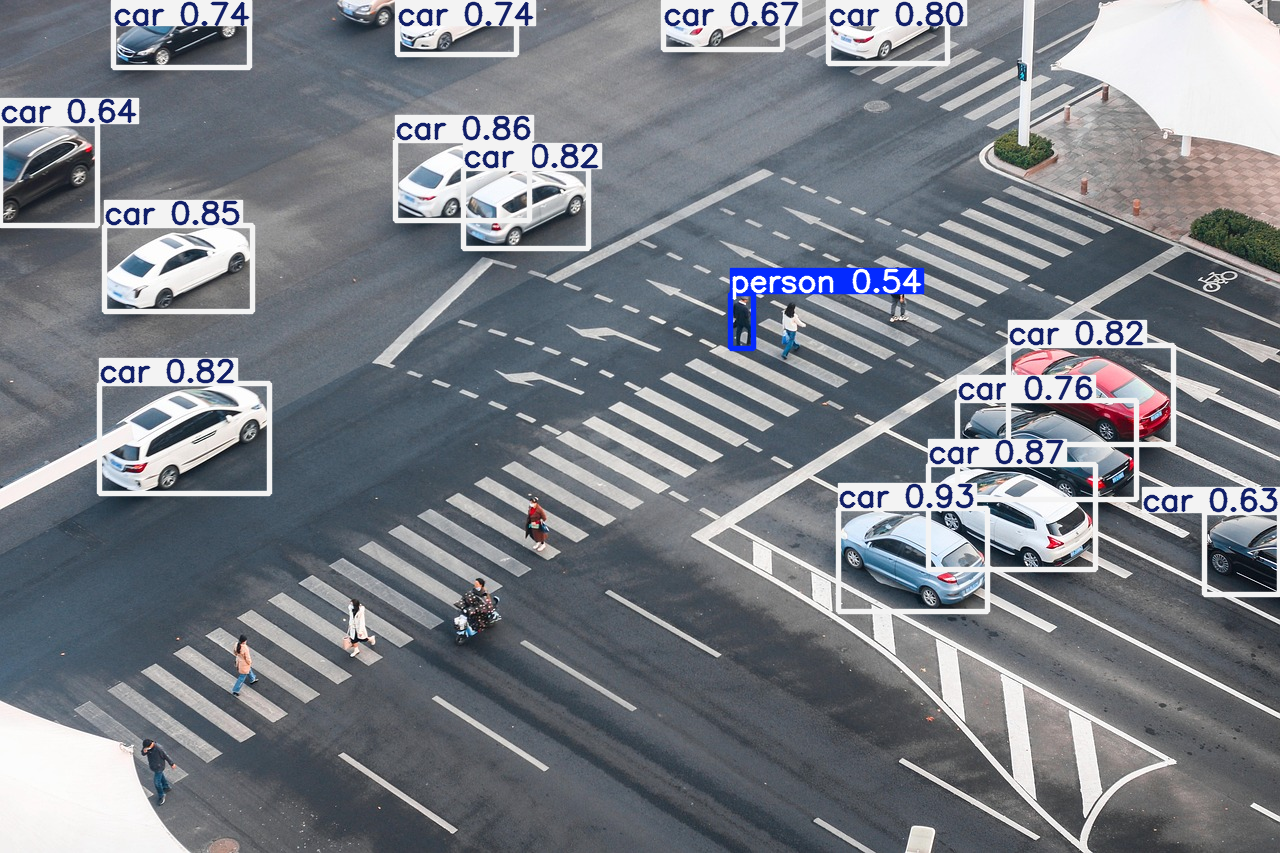

In [1]:
# ==============================
# 1. Install required library
# ==============================
!pip install ultralytics -q

# ==============================
# 2. Import libraries
# ==============================
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# ==============================
# 3. Upload Image
# ==============================
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# ==============================
# 4. Load YOLOv8 Model
# ==============================
model = YOLO('yolov8n.pt')   # nano model (fastest)

# ==============================
# 5. Perform Detection
# ==============================
results = model(image_path, conf=0.5)

# ==============================
# 6. Print Detection Results
# ==============================
for result in results:
    boxes = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]

        print(f'{cls_name}: {conf:.2f} at [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]')

# ==============================
# 7. Show Output Image
# ==============================
annotated_image = results[0].plot()
cv2_imshow(annotated_image)